In [7]:
import pandas as pd
df = pd.read_excel(r'C:/Users/HP/OneDrive/Desktop/ai_impact_jobs_2010_2025.csv.xlsx')
df.head()

,job_id,posting_year,country,region,city,company_name,company_size,industry,job_title,seniority_level,...,ai_intensity_score,core_skills,ai_skills,salary_usd,salary_change_vs_prev_year_percent,automation_risk_score,reskilling_required,ai_job_displacement_risk,job_description_embedding_cluster,industry_ai_adoption_stage
0,836b4774-702e-49ef-93d3-2f255ce1e910,2018,Brazil,South America,London,NextGen Technologies,Small,Education,Policy Analyst,Lead,...,0.81,"Research, Project Management, Business Analysis",reinforcement learning,61586,12.68,0.11,True,Low,14,Growing
1,43699e93-7b15-4728-a4c6-9e41ff438a25,2015,UAE,Middle East,Singapore,Future Solutions,Medium,Energy,Data Scientist,Executive,...,0.04,"Research, SQL, Business Analysis, Python, Clou...",NaN,62045,-3.98,0.71,False,High,19,Emerging
2,fc9d1854-3cbf-4bab-90df-77304dfc59df,2016,Nepal,South Asia,Sydney,Future Analytics,Startup,Finance,Product Manager,Junior,...,0.15,"Statistics, Project Management, Cloud Computin...",NaN,27035,3.55,0.86,False,High,2,Emerging
3,05c1c7d3-2add-4919-91eb-f6c78bfe23d1,2015,Spain,Europe,Nairobi,Global Technologies,Large,Government,Data Scientist,Mid,...,0.19,"Cloud Computing, SQL, Project Management, Comm...",NaN,72894,-2.80,0.70,False,Low,15,Emerging
4,5e739937-d1b0-44d7-935c-7ebb3fc1f6e8,2014,Taiwan,East Asia,Sydney,Future Technologies,Small,Manufacturing,ML Engineer,Lead,...,0.11,"SQL, Python, Communication, Software Engineeri...",NaN,57215,0.85,0.87,False,High,13,Emerging


In [8]:
print(df.columns)
print(df.dtypes)
print(df.describe())

Index(['job_id', 'posting_year', 'country', 'region', 'city', 'company_name',
       'company_size', 'industry', 'job_title', 'seniority_level',
       'ai_mentioned', 'ai_keywords', 'ai_intensity_score', 'core_skills',
       'ai_skills', 'salary_usd', 'salary_change_vs_prev_year_percent',
       'automation_risk_score', 'reskilling_required',
       'ai_job_displacement_risk', 'job_description_embedding_cluster',
       'industry_ai_adoption_stage'],
      dtype='object')
job_id                                 object
posting_year                            int64
country                                object
region                                 object
city                                   object
company_name                           object
company_size                           object
industry                               object
job_title                              object
seniority_level                        object
ai_mentioned                             bool
ai_keywords    

In [9]:
# Remove duplicates
df = df.drop_duplicates()

# Check null values
print(df.isnull().sum())

# Fill missing numeric values with 0
numeric_cols = df.select_dtypes(include=['int64','float64']).columns
df[numeric_cols] = df[numeric_cols].fillna(0)

# Strip text columns
text_cols = df.select_dtypes(include=['object']).columns
df[text_cols] = df[text_cols].apply(lambda x: x.str.strip())

print("Cleaning Complete")

job_id                                   0
posting_year                             0
country                                  0
region                                   0
city                                     0
company_name                             0
company_size                             0
industry                                 0
job_title                                0
seniority_level                          0
ai_mentioned                             0
ai_keywords                           3377
ai_intensity_score                       0
core_skills                              0
ai_skills                             3377
salary_usd                               0
salary_change_vs_prev_year_percent       0
automation_risk_score                    0
reskilling_required                      0
ai_job_displacement_risk                 0
job_description_embedding_cluster        0
industry_ai_adoption_stage               0
dtype: int64
Cleaning Complete


In [10]:
print(df.columns)

Index(['job_id', 'posting_year', 'country', 'region', 'city', 'company_name',
       'company_size', 'industry', 'job_title', 'seniority_level',
       'ai_mentioned', 'ai_keywords', 'ai_intensity_score', 'core_skills',
       'ai_skills', 'salary_usd', 'salary_change_vs_prev_year_percent',
       'automation_risk_score', 'reskilling_required',
       'ai_job_displacement_risk', 'job_description_embedding_cluster',
       'industry_ai_adoption_stage'],
      dtype='object')


In [11]:
# Convert boolean-like columns
df['ai_mentioned'] = df['ai_mentioned'].astype(int)
df['reskilling_required'] = df['reskilling_required'].astype(int)

# Fill missing numeric values
numeric_cols = df.select_dtypes(include=['int64','float64']).columns
df[numeric_cols] = df[numeric_cols].fillna(0)

# Fill text columns
text_cols = df.select_dtypes(include=['object']).columns
df[text_cols] = df[text_cols].fillna("Unknown")

print("Data cleaned successfully")

Data cleaned successfully


In [19]:
conn = pyodbc.connect(
    r'DRIVER={ODBC Driver 17 for SQL Server};'
    r'SERVER=LAPTOP-1INDQFVG\MSSQL;'
    r'DATABASE=AI_Job_Impact;'
    r'Trusted_Connection=yes;'
)

cursor = conn.cursor()

cursor.execute("SELECT DB_NAME()")
print(cursor.fetchone())

for index, row in df.iterrows():
    try:
        cursor.execute("""
            INSERT INTO Jobs VALUES (?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?)
        """,
            row.job_id,
            int(row.posting_year),
            row.country,
            row.region,
            row.city,
            row.company_name,
            row.company_size,
            row.industry,
            row.job_title,
            row.seniority_level,
            int(row.ai_mentioned),
            row.ai_keywords,
            float(row.ai_intensity_score),
            row.core_skills,
            row.ai_skills,
            float(row.salary_usd),
            float(row.salary_change_vs_prev_year_percent),
            float(row.automation_risk_score),
            int(row.reskilling_required),
            row.ai_job_displacement_risk,
            int(row.job_description_embedding_cluster),
            row.industry_ai_adoption_stage
        )
    except Exception as e:
        print("Error at row:", index)
        print(e)
        break

conn.commit()
conn.close()

print("Insertion completed")

('AI_Job_Impact',)
Insertion completed


In [17]:
print(df.dtypes)

job_id                                 object
posting_year                            int64
country                                object
region                                 object
city                                   object
company_name                           object
company_size                           object
industry                               object
job_title                              object
seniority_level                        object
ai_mentioned                            int64
ai_keywords                            object
ai_intensity_score                    float64
core_skills                            object
ai_skills                              object
salary_usd                              int64
salary_change_vs_prev_year_percent    float64
automation_risk_score                 float64
reskilling_required                     int64
ai_job_displacement_risk               object
job_description_embedding_cluster       int64
industry_ai_adoption_stage        

Matplotlib is building the font cache; this may take a moment.


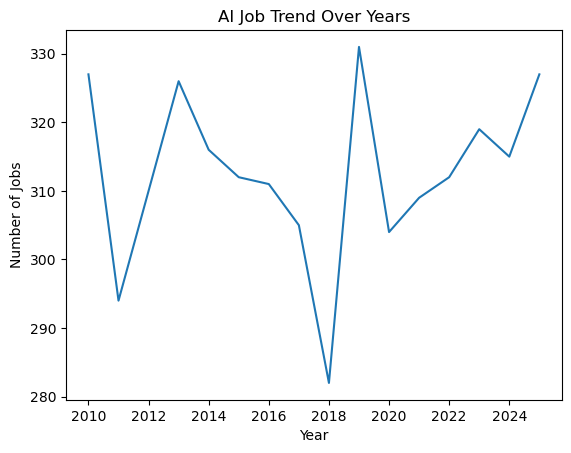

In [20]:
import matplotlib.pyplot as plt

df.groupby('posting_year').size().plot(kind='line')
plt.title("AI Job Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Jobs")
plt.show()

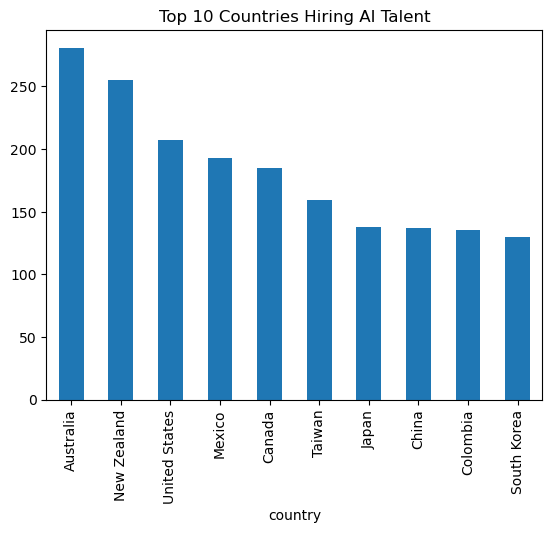

In [21]:
top_countries = df['country'].value_counts().head(10)

top_countries.plot(kind='bar')
plt.title("Top 10 Countries Hiring AI Talent")
plt.show()

In [22]:
df.groupby('industry')['salary_usd'].mean().sort_values(ascending=False).head(10)

industry
Tech             66262.012090
Finance          65276.938069
Government       63088.815018
Manufacturing    62882.090750
Energy           62725.852490
Healthcare       62502.042857
Education        62098.826168
Retail           61822.220459
Agriculture      61125.024605
Name: salary_usd, dtype: float64

In [23]:
df.groupby('ai_intensity_score')['salary_usd'].mean()

ai_intensity_score
0.00    48264.078947
0.01    52928.651429
0.02    54085.735632
0.03    54101.638037
0.04    52400.553763
            ...     
0.91    78414.804878
0.92    81418.440000
0.93    81050.727273
0.94    88518.424242
0.95    90713.434783
Name: salary_usd, Length: 77, dtype: float64

In [24]:
def categorize_ai(score):
    if score < 0.3:
        return 'Low'
    elif score < 0.7:
        return 'Medium'
    else:
        return 'High'

df['AI_Level'] = df['ai_intensity_score'].apply(categorize_ai)

df.groupby('AI_Level')['salary_usd'].mean()

AI_Level
High      82294.397683
Low       53123.575363
Medium    85271.705674
Name: salary_usd, dtype: float64

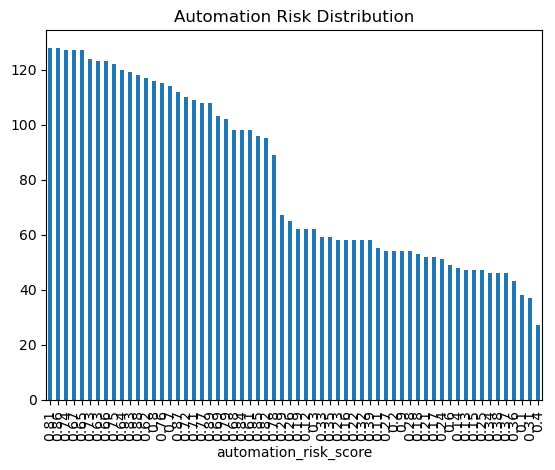

In [25]:
df['automation_risk_score'].value_counts().plot(kind='bar')
plt.title("Automation Risk Distribution")
plt.show()